In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler 

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 

from sklearn.linear_model import LogisticRegression


### 1. Data Loading and Initial Exploration 


In [2]:
df = pd.read_csv('titanic_data_updated (1).csv') 

df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
261,262,yes,third,"Asplund, Master. Edvin Rojj Felix",male,3.0,4,2,347077,31.3875,NaN,S
54,55,no,first,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
208,209,yes,third,"Carr, Miss. Helen ""Ellen""",female,16.0,0,0,367231,7.7500,NaN,Q
768,769,no,third,"Moran, Mr. Daniel J",male,NaN,1,0,371110,24.1500,NaN,Q
615,616,yes,second,"Herman, Miss. Alice",female,24.0,1,2,220845,65.0000,NaN,S


In [3]:
df['Cabin'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Cabin
Non-Null Count  Dtype 
--------------  ----- 
204 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


### Feature Engineering 

In [14]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1 
df['Cabin'] = df['Cabin'].fillna("Missing") 

df['Deck'] = df['Cabin'].astype(str).str[0] 
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Family_Size,Deck
382,no,third,male,32.0,0,0,7.925,Missing,S,1,M
839,yes,first,male,NaN,0,0,29.700,C47,C,1,C
543,yes,second,male,32.0,1,0,26.000,Missing,S,2,M
665,no,second,male,32.0,2,0,73.500,Missing,S,3,M
274,yes,third,female,NaN,0,0,7.750,Missing,Q,1,M


In [15]:
df['Deck'].value_counts()

Deck
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [16]:
X = df.drop('Survived', axis =1) 
y = df['Survived']

In [17]:
y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [18]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42, stratify=y)

In [12]:
X_train

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Deck
692,693,third,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,Missing,S,1,M
481,482,second,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,Missing,S,1,M
527,528,first,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S,1,C
855,856,third,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,Missing,S,2,M
801,802,second,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,Missing,S,3,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,360,third,"Mockler, Miss. Helen Mary ""Ellie""",female,NaN,0,0,330980,7.8792,Missing,Q,1,M
258,259,first,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,Missing,C,1,M
736,737,third,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.3750,Missing,S,5,M
462,463,first,"Gee, Mr. Arthur H",male,47.0,0,0,111320,38.5000,E63,S,1,E


<Axes: xlabel='Survived', ylabel='count'>

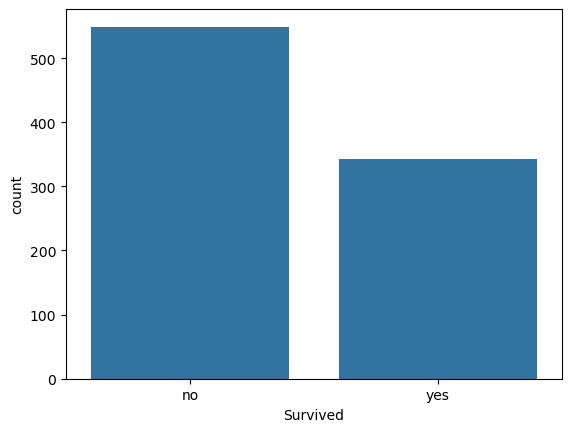

In [19]:
sns.countplot(data=df, x=df['Survived'])

### ML Pipeline

In [23]:
# imputer_transformers = ColumnTransformer(
#     transformers=[
#         ('age',SimpleImputer(missing_values=np.nan,strategy='mean'),['Age']),
#         ('emabarked',SimpleImputer(missing_values=np.nan, strategy='most_frequent'),['Embarked']),
#         ('cabin',SimpleImputer(missing_values=np.nan, strategy='constant',fill_value='Missing', add_indicator=True),['Cabin'])
#     ],
#     remainder='passthrough',
#     verbose_feature_names_out=False
    
# )

# imputer_transformers.set_output(transform='pandas')
# imputer_transformers.fit(X_train)
# X_train = imputer_transformers.transform(X_train) 
# X_test = imputer_transformers.transform(X_test)

In [26]:
# Numerical values 

p1 = Pipeline(
    steps=[
        ('Imputer', SimpleImputer(strategy='mean')),
        ('scaler',StandardScaler())
    ]
)

p2 = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',MinMaxScaler())
        
    ]
)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', MinMaxScaler())])

In [29]:
categories=[['third','second','first']]

In [33]:
# Categorical values 

p3 = Pipeline(
    steps=[
        ('Imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(sparse_output=False,drop='first'))
    ]
)

p4 = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=categories,handle_unknown='ignore')),
        ('scaler',MinMaxScaler())
        
    ]
)
p4

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OrdinalEncoder(categories=[['third', 'second', 'first']],
                                handle_unknown='ignore')),
                ('scaler', MinMaxScaler())])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[]
)

### Designing preprocessor 